In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

In [2]:
data=pd.read_csv("data.csv")

In [3]:
data.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
279912,169174.0,-1.525129,-0.481216,-0.502442,-4.022658,1.770233,3.429139,-0.954343,1.319457,-2.348824,...,-0.206243,-0.242489,-0.004702,0.675484,0.893525,-0.088809,-0.045240,0.007929,10.00,0
3508,2998.0,-0.302521,0.447474,-0.495757,-3.214799,2.705041,2.762440,0.593847,0.556451,0.697720,...,0.007343,0.250886,-0.331600,1.009952,0.233730,-0.824471,0.241305,-0.020359,1.00,0
256066,157525.0,-0.707409,1.337308,-0.665680,-0.776085,1.421832,-0.626937,0.819334,0.203875,-0.665635,...,0.284874,0.737732,-0.474702,-0.002633,0.408023,-0.123133,0.015601,0.076475,2.36,0
105573,69594.0,-0.791983,0.514760,1.475528,2.642128,1.156046,1.917620,-0.089654,0.716586,-1.494685,...,0.060743,0.287741,0.628789,-1.087731,-1.310856,-0.040831,0.176589,0.161859,10.00,0
261923,160243.0,0.188666,0.952246,-0.674767,-0.673689,1.118282,-0.518991,0.895240,-0.017464,0.140392,...,-0.392628,-1.024911,0.031711,-0.045580,-0.373618,0.152764,0.215386,0.076161,2.69,0


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

There are no missing values.

In [5]:
data.duplicated().sum()

np.int64(1081)

In [6]:
data=data.drop_duplicates()

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [9]:
data["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [10]:
data["Class"].value_counts(normalize=True)*100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

We can see that only 0.167 percent of transactions are fraudulent. Hence, the data is highly imbalanced.

In [11]:
#Time is in seconds.It's need to be conveted into hours
data["Time"]=data["Time"]/3600

In [12]:
data["Time"].describe()

count    283726.000000
mean         26.336410
std          13.189180
min           0.000000
25%          15.056875
50%          23.525694
75%          38.693889
max          47.997778
Name: Time, dtype: float64

In [13]:
data["Time"].skew()

np.float64(-0.0355806462359829)

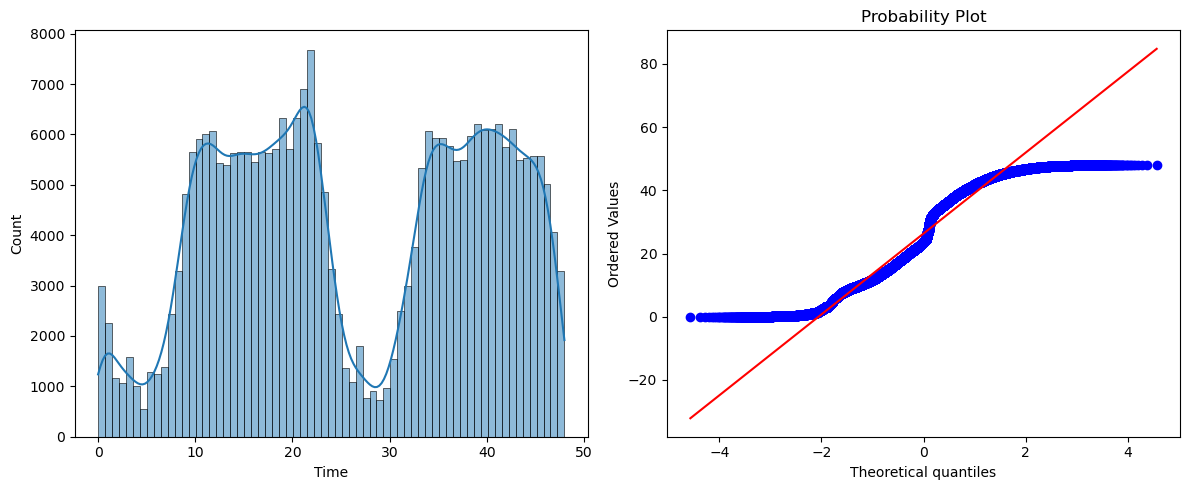

In [14]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data["Time"],kde=True)

plt.subplot(1,2,2)
stats.probplot(data["Time"],dist='norm',plot=plt)
plt.tight_layout()

In [15]:
data["Amount"].skew()

np.float64(16.978803370060476)

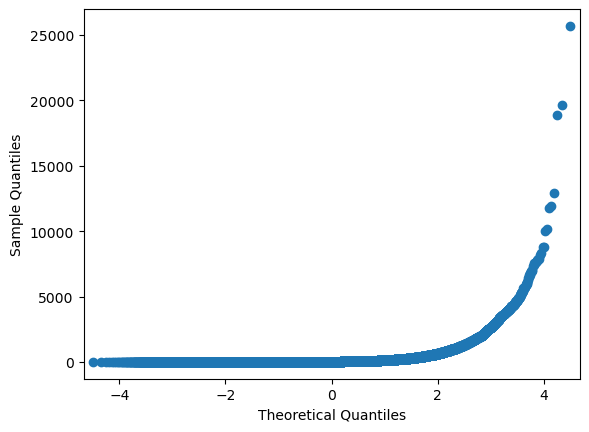

In [16]:
sm.qqplot(data["Amount"])
plt.show()

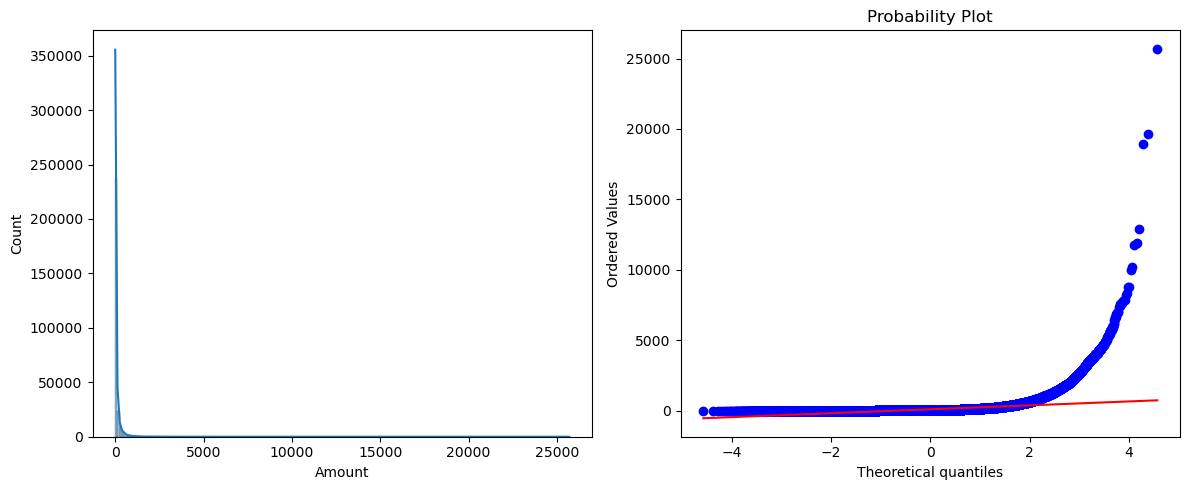

In [17]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data["Amount"],bins=200,kde=True)

plt.subplot(1,2,2)
stats.probplot(data["Amount"],dist='norm',plot=plt)
plt.tight_layout()

We can see that the Amount column is highly positively skewed.
So, we need to transform that.

In [18]:
for col in data:
    print(col,data[col].skew()) 

Time -0.0355806462359829
V1 -3.273271248440311
V2 -4.695161900540468
V3 -2.151983957099712
V4 0.6715041706728239
V5 -2.414079246966253
V6 1.8298803837715212
V7 2.8902711927154967
V8 -8.310970330052546
V9 0.5376630534496958
V10 1.2529670787468168
V11 0.34407419325686256
V12 -2.1990082816149945
V13 0.06429340464018107
V14 -1.9188037137586458
V15 -0.3096590822936595
V16 -1.051161471517466
V17 -3.690497194148407
V18 -0.24866145737243991
V19 0.1083118109324772
V20 -2.0431210560273327
V21 2.820033113572543
V22 -0.18232972797521257
V23 -5.86722079100634
V24 -0.5521292366718961
V25 -0.415743862054696
V26 0.5802923172348096
V27 -0.7538039138186546
V28 11.555115084196773
Amount 16.978803370060476
Class 24.430545072372148


We can see many of these are skewed specially V28 but since they are principal components obtained with PCA ,we don't perform further transformation.

In [19]:
corr=data.corr()

<Axes: >

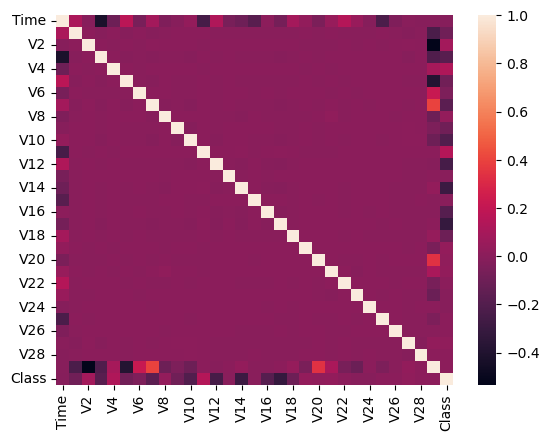

In [20]:
sns.heatmap(corr)

We can see that V28 feature correlates more than the other features.

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X=data.drop(columns=['Class'])
y=data['Class']

In [23]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,stratify=data['Class'],random_state=42)

In [24]:
X_train.shape

(226980, 30)

In [25]:
X_test.shape

(56746, 30)

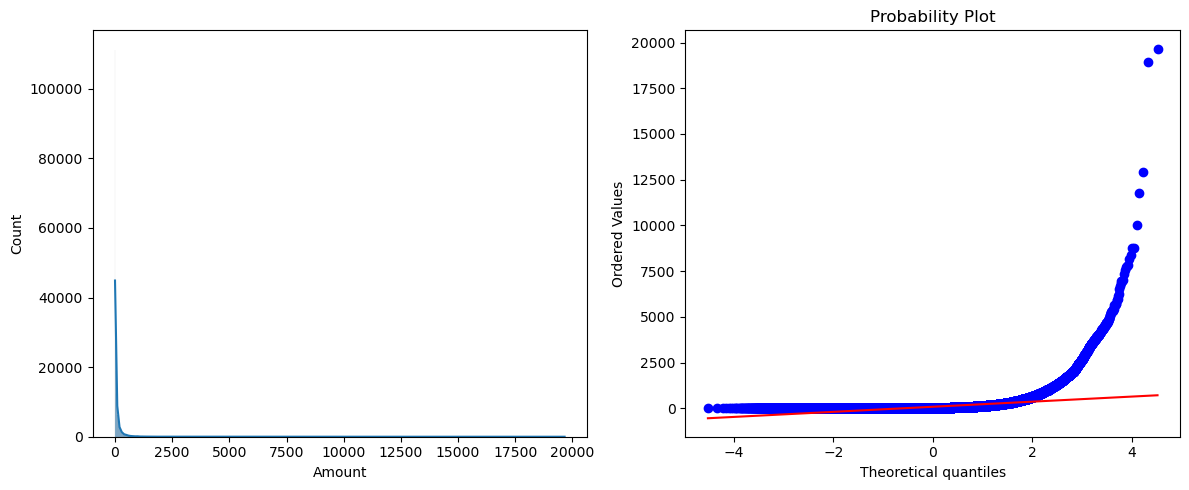

In [26]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(X_train["Amount"],kde=True)

plt.subplot(1,2,2)
stats.probplot(X_train["Amount"],dist='norm',plot=plt)
plt.tight_layout()

C:\Users\pragy\AppData\Local\Temp\ipykernel_4388\1675597916.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Time"])


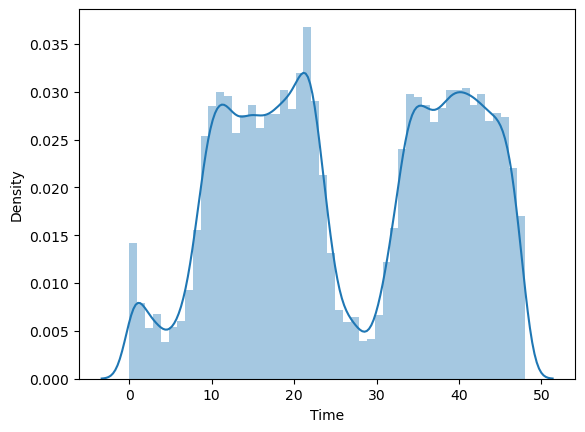

((array([-4.52263148, -4.33127155, -4.22744106, ...,  4.22744106,
          4.33127155,  4.52263148], shape=(226980,)),
  array([0.00000000e+00, 0.00000000e+00, 2.77777778e-04, ...,
         4.79966667e+01, 4.79966667e+01, 4.79977778e+01], shape=(226980,))),
 (np.float64(12.78839436355671),
  np.float64(26.361173441615023),
  np.float64(0.9694483938510553)))

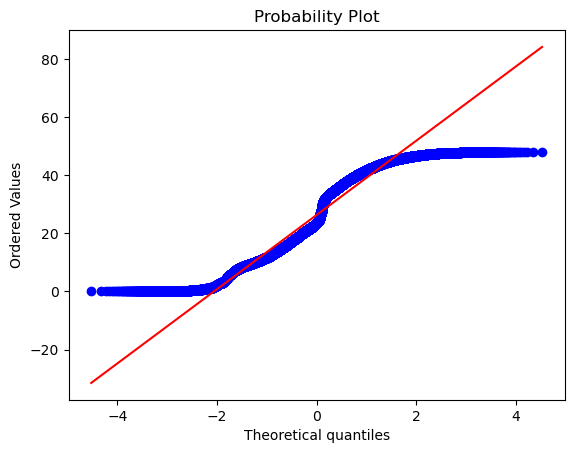

In [27]:
sns.distplot(X_train["Time"])
plt.show()
stats.probplot(X_train["Time"],dist="norm",plot=plt)

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, f1_score ,recall_score

In [29]:
from sklearn.preprocessing import StandardScaler , FunctionTransformer , PowerTransformer


In [30]:
X_train_copy=X_train.copy()
X_test_copy=X_test.copy()

#Preprocessing

Features(V1 to V28) in the dataset are PCA transformed and already standardized. 
Therefore only Time and Amount require preprocessing.

We will ,first, transform Amount using log function then scale Time and Amount both.

In [31]:
tf_log=FunctionTransformer(func=np.log1p)
tf_cb_root=FunctionTransformer(func=np.cbrt)
tf_yeo_jh=PowerTransformer()       #yeo-jhonson

In [32]:
transformations=[tf_log,tf_cb_root,tf_yeo_jh]

In [33]:
X_train_copy['Amount'].skew()

np.float64(14.393212212999096)

In [34]:
for name in transformations:
    X_train_copy['Amount']=name.fit_transform(X_train[['Amount']])
    print (X_train_copy["Amount"].skew())

0.15913383255449665
1.4851597029589485
0.01795422206945477


So we can see that yeo jhonson method provides with the least skewness so we will use this transformation.

In [35]:
X_train_copy['Amount']=tf_yeo_jh.fit_transform(X_train[['Amount']])
X_test_copy['Amount']=tf_yeo_jh.transform(X_test[['Amount']])

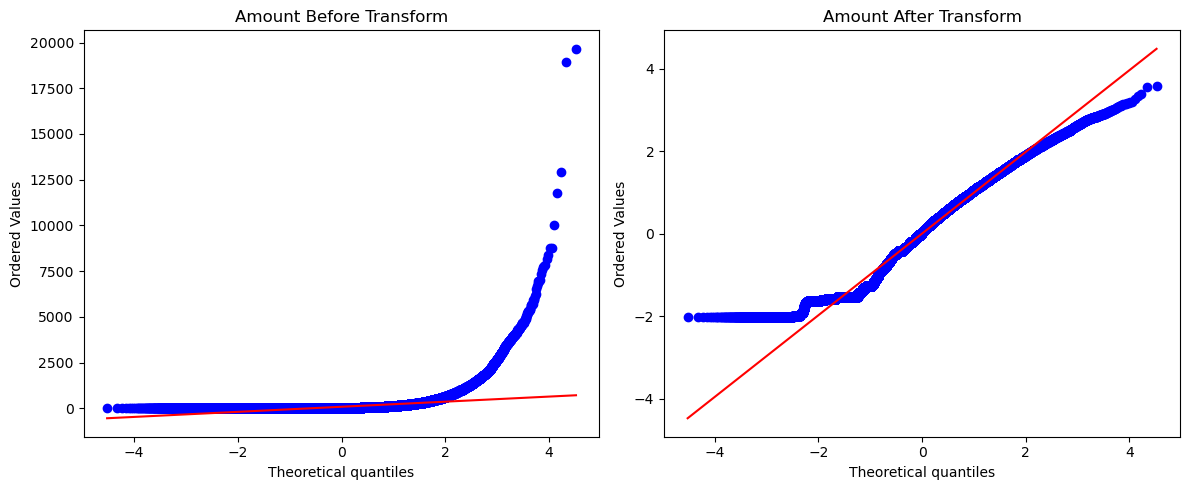

In [36]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
stats.probplot(X_train["Amount"],dist='norm',plot=plt)
plt.title('Amount Before Transform')

plt.subplot(1,2,2)
stats.probplot(X_train_copy["Amount"],dist='norm',plot=plt)
plt.title('Amount After Transform')
plt.tight_layout()

In [37]:
scaler=StandardScaler()

In [38]:
X_train_copy[['Time','Amount']]= scaler.fit_transform(X_train_copy[['Time','Amount']])
X_test_copy[['Time','Amount']]=scaler.transform(X_test_copy[['Time','Amount']])

In [39]:
from imblearn.under_sampling import RandomUnderSampler

In [40]:
from imblearn.over_sampling import SMOTE

In [41]:
rus=RandomUnderSampler(random_state=42)

In [42]:
sm=SMOTE(random_state=42)

In [43]:
lr1=LogisticRegression()

In [44]:
lr2=LogisticRegression()

In [45]:
lr3=LogisticRegression(class_weight='balanced')

In [47]:
X_resampled1,y_resampled1=rus.fit_resample(X_train_copy,y_train)

In [48]:
X_resampled2,y_resampled2=sm.fit_resample(X_train_copy,y_train)

#Model Training

In [49]:
lr1.fit(X_resampled1,y_resampled1)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [50]:
lr2.fit(X_resampled2,y_resampled2)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [51]:
lr3.fit(X_train_copy,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [52]:
pred1=lr1.predict(X_test_copy)

In [53]:
pred2=lr2.predict(X_test_copy)

In [54]:
pred3=lr3.predict(X_test_copy)

In [55]:
print("precision")
print("unsampling",precision_score(y_test,pred1))
print("smote",precision_score(y_test,pred2))
print("class weights",precision_score(y_test,pred3))
print("------")

print("recall")
print("unsampling",recall_score(y_test,pred1))
print("smote",recall_score(y_test,pred2))
print("class weights",recall_score(y_test,pred3))
print("------")

print("f1")
print("unsampling",f1_score(y_test,pred1))
print("smote",f1_score(y_test,pred2))
print("class weights",f1_score(y_test,pred3))

precision
unsampling 0.051681195516811954
smote 0.05283259070655633
class weights 0.0552964690206529
------
recall
unsampling 0.8736842105263158
smote 0.8736842105263158
class weights 0.8736842105263158
------
f1
unsampling 0.0975896531452087
smote 0.09963985594237695
class weights 0.10401002506265664


In [66]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [67]:
dt1 = DecisionTreeClassifier(max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42)
dt2 = DecisionTreeClassifier(max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42)
dt3 = DecisionTreeClassifier(max_depth=10, min_samples_split=10, min_samples_leaf=5, class_weight='balanced', random_state=42)

In [68]:
dt1.fit(X_resampled1, y_resampled1)
dt2.fit(X_resampled2, y_resampled2)
dt3.fit(X_train_copy, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [69]:
dt_pred1 = dt1.predict(X_test_copy)
dt_pred2 = dt2.predict(X_test_copy)
dt_pred3 = dt3.predict(X_test_copy)

In [70]:
print("DECISION TREE PERFORMANCE")

print("\nPrecision")
print("UnderSampling:", precision_score(y_test, dt_pred1))
print("SMOTE:", precision_score(y_test, dt_pred2))
print("Class Weights:", precision_score(y_test, dt_pred3))

print("\nRecall")
print("UnderSampling:", recall_score(y_test, dt_pred1))
print("SMOTE:", recall_score(y_test, dt_pred2))
print("Class Weights:", recall_score(y_test, dt_pred3))

print("\nF1-Score")
print("UnderSampling:", f1_score(y_test, dt_pred1))
print("SMOTE:", f1_score(y_test, dt_pred2))
print("Class Weights:", f1_score(y_test, dt_pred3))

DECISION TREE PERFORMANCE

Precision
UnderSampling: 0.02246893999471319
SMOTE: 0.08788598574821853
Class Weights: 0.22560975609756098

Recall
UnderSampling: 0.8947368421052632
SMOTE: 0.7789473684210526
Class Weights: 0.7789473684210526

F1-Score
UnderSampling: 0.043837029396596186
SMOTE: 0.15795090715048027
Class Weights: 0.34988179669030733


In [71]:
# Random Forest Models
rf1 = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf2 = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf3 = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=10, min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1)



In [72]:
rf1.fit(X_resampled1, y_resampled1)
rf2.fit(X_resampled2, y_resampled2)
rf3.fit(X_train_copy, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [73]:
rf_pred1 = rf1.predict(X_test_copy)
rf_pred2 = rf2.predict(X_test_copy)
rf_pred3 = rf3.predict(X_test_copy)


In [74]:
print("RANDOM FOREST PERFORMANCE")

print("\nPrecision")
print("UnderSampling:", precision_score(y_test, rf_pred1))
print("SMOTE:", precision_score(y_test, rf_pred2))
print("Class Weights:", precision_score(y_test, rf_pred3))

print("\nRecall")
print("UnderSampling:", recall_score(y_test, rf_pred1))
print("SMOTE:", recall_score(y_test, rf_pred2))
print("Class Weights:", recall_score(y_test, rf_pred3))

print("\nF1-Score")
print("UnderSampling:", f1_score(y_test, rf_pred1))
print("SMOTE:", f1_score(y_test, rf_pred2))
print("Class Weights:", f1_score(y_test, rf_pred3))



RANDOM FOREST PERFORMANCE

Precision
UnderSampling: 0.08817204301075268
SMOTE: 0.7731958762886598
Class Weights: 0.9210526315789473

Recall
UnderSampling: 0.8631578947368421
SMOTE: 0.7894736842105263
Class Weights: 0.7368421052631579

F1-Score
UnderSampling: 0.16
SMOTE: 0.78125
Class Weights: 0.8187134502923976


In [75]:
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve

In [77]:
print("ROC-AUC SCORES")

ROC-AUC SCORES


In [76]:
# Logistic Regression
print("\nLogistic Regression:")
print("UnderSampling:", roc_auc_score(y_test, lr1.predict_proba(X_test_copy)[:, 1]))
print("SMOTE:", roc_auc_score(y_test, lr2.predict_proba(X_test_copy)[:, 1]))
print("Class Weights:", roc_auc_score(y_test, lr3.predict_proba(X_test_copy)[:, 1]))

# Decision Tree
print("\nDecision Tree:")
print("UnderSampling:", roc_auc_score(y_test, dt1.predict_proba(X_test_copy)[:, 1]))
print("SMOTE:", roc_auc_score(y_test, dt2.predict_proba(X_test_copy)[:, 1]))
print("Class Weights:", roc_auc_score(y_test, dt3.predict_proba(X_test_copy)[:, 1]))

# Random Forest
print("\nRandom Forest:")
print("UnderSampling:", roc_auc_score(y_test, rf1.predict_proba(X_test_copy)[:, 1]))
print("SMOTE:", roc_auc_score(y_test, rf2.predict_proba(X_test_copy)[:, 1]))
print("Class Weights:", roc_auc_score(y_test, rf3.predict_proba(X_test_copy)[:, 1]))


Logistic Regression:
UnderSampling: 0.9573673154838165
SMOTE: 0.9588981102205656
Class Weights: 0.9625008709838355

Decision Tree:
UnderSampling: 0.9349400623763783
SMOTE: 0.8763286568082136
Class Weights: 0.8886976492262412

Random Forest:
UnderSampling: 0.9711266303656088
SMOTE: 0.9834079205179637
Class Weights: 0.9458471955249548


In [80]:
# Make fresh copies
X_train_final = X_train.copy()
X_test_final = X_test.copy()

#Transform
amount_transformer = PowerTransformer(method='yeo-johnson')

X_train_final['Amount'] = amount_transformer.fit_transform(
    X_train_final[['Amount']]
)

X_test_final['Amount'] = amount_transformer.transform(
    X_test_final[['Amount']]
)

#Scale

scaler_final = StandardScaler()

X_train_final[['Time', 'Amount']] = scaler_final.fit_transform(
    X_train_final[['Time', 'Amount']]
)

X_test_final[['Time', 'Amount']] = scaler_final.transform(
    X_test_final[['Time', 'Amount']])

In [81]:
# ==============================
# SMOTE
# ==============================

smote_final = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote_final.fit_resample(
    X_train_final,
    y_train
)

print("Original training data:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Original training data:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


In [82]:
final_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_smote, y_train_smote)

print("Final model trained successfully.")

Final model trained successfully.


In [84]:
import joblib
# SAVE MODEL + PREPROCESSING

joblib.dump(final_model, "fraud_model.pkl")
joblib.dump(amount_transformer, "amount_transformer.pkl")
joblib.dump(scaler_final, "scaler.pkl")

print("All files saved successfully.")

All files saved successfully.


In [85]:
# TEST SAVED MODEL


loaded_model = joblib.load("fraud_model.pkl")
loaded_amount_transformer = joblib.load("amount_transformer.pkl")
loaded_scaler = joblib.load("scaler.pkl")

print("Models loaded successfully.")

Models loaded successfully.


In [86]:
# Take one transaction from test data

sample = X_test.iloc[[0]].copy()

# Transform Amount
sample['Amount'] = loaded_amount_transformer.transform(
    sample[['Amount']]
)

# Scale Time and Amount
sample[['Time', 'Amount']] = loaded_scaler.transform(
    sample[['Time', 'Amount']]
)

prediction = loaded_model.predict(sample)[0]
probability = loaded_model.predict_proba(sample)[0][1]

print("Prediction:", prediction)
print("Fraud Probability:", probability)

Prediction: 0
Fraud Probability: 0.0014924066898128337
